# Model Interpretability: SHAP and LIME Analysis
## AQI Prediction Model - Karachi, Pakistan

This notebook provides comprehensive model interpretability analysis using:
- **SHAP (SHapley Additive exPlanations)**: Global and local feature importance
- **LIME (Local Interpretable Model-agnostic Explanations)**: Individual prediction explanations

### Objectives:
1. Understand which features drive AQI predictions
2. Analyze feature interactions and dependencies
3. Explain individual predictions
4. Compare SHAP vs LIME insights

## 1. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Model interpretability
import shap
from lime import lime_tabular

# ML libraries
from sklearn.model_selection import train_test_split

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"   SHAP version: {shap.__version__}")

✅ All libraries imported successfully!
   SHAP version: 0.48.0


## 2. Configuration

In [2]:
# Paths
MODELS_DIR = r"C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\models"
DATA_PATH = r"C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\data\processed\features.csv"
OUTPUT_DIR = r"C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\notebooks\interpretability_outputs"
TARGET_VARIABLE = "us_aqi"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ Configuration set")
print(f"   Models directory: {MODELS_DIR}")
print(f"   Data path: {DATA_PATH}")
print(f"   Output directory: {OUTPUT_DIR}")

✅ Configuration set
   Models directory: C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\models
   Data path: C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\data\processed\features.csv
   Output directory: C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\notebooks\interpretability_outputs


## 3. Load and Prepare Data

**CRITICAL**: This cell replicates the exact feature engineering from `train_model.py` to ensure feature alignment with trained models.

In [3]:
print("="*70)
print("📊 LOADING AND PREPARING DATA")
print("="*70)

# Load base data
print("\n1️⃣ Loading base features...")
df = pd.read_csv(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
print(f"   Loaded {len(df)} rows, {len(df.columns)} columns")

# Create lag features (EXACTLY as in train_model.py)
print("\n2️⃣ Creating lag features...")
lags_to_add = [1, 2, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168]

for lag in lags_to_add:
    col_name = f'aqi_lag_{lag}h'
    if col_name not in df.columns:
        df[col_name] = df[TARGET_VARIABLE].shift(lag)
        
print(f"   Created {len(lags_to_add)} lag features")

# Create rolling features (EXACTLY as in train_model.py)
print("\n3️⃣ Creating rolling statistics...")
for window in [6, 12, 24, 72]:
    col_mean = f'aqi_rolling_mean_{window}h'
    if col_mean not in df.columns:
        df[col_mean] = df[TARGET_VARIABLE].shift(24).rolling(window).mean()
    
    col_std = f'aqi_rolling_std_{window}h'
    if col_std not in df.columns:
        df[col_std] = df[TARGET_VARIABLE].shift(24).rolling(window).std()

print(f"   Created {4*2} rolling features (mean + std for 4 windows)")

# Remove european_aqi if exists
if 'european_aqi' in df.columns:
    df = df.drop(columns=['european_aqi'])

# Drop NaN values
df_clean = df.dropna()
print(f"\n4️⃣ Cleaned data: {len(df_clean)} samples (dropped {len(df) - len(df_clean)} NaN rows)")

print("\n" + "="*70)
print("✅ DATA PREPARATION COMPLETE")
print("="*70)

📊 LOADING AND PREPARING DATA

1️⃣ Loading base features...
   Loaded 26280 rows, 32 columns

2️⃣ Creating lag features...
   Created 12 lag features

3️⃣ Creating rolling statistics...
   Created 8 rolling features (mean + std for 4 windows)

4️⃣ Cleaned data: 26112 samples (dropped 168 NaN rows)

✅ DATA PREPARATION COMPLETE


## 4. Load Trained Models

In [4]:
print("🤖 Loading trained models...\n")

models = {}

# Model patterns (focusing on day1 models for analysis)
model_patterns = {
    'catboost_day1': 'aqi_predictor_catboost_day1_*.pkl',
    'xgboost_day1': 'aqi_predictor_xgboost_day1_*.pkl',
    'lightgbm_day1': 'aqi_predictor_lightgbm_day1_*.pkl',
}

for model_name, pattern in model_patterns.items():
    model_files = glob.glob(os.path.join(MODELS_DIR, pattern))
    
    if model_files:
        latest_model = max(model_files, key=os.path.getmtime)
        
        try:
            model_data = joblib.load(latest_model)
            models[model_name] = model_data
            metrics = model_data['metrics']
            
            print(f"✅ Loaded: {model_name}")
            print(f"   File: {os.path.basename(latest_model)}")
            print(f"   Test R²: {metrics['test_r2']:.3f} | MAE: {metrics['test_mae']:.2f}")
            print(f"   CV R²: {metrics['cv_mean_test_r2']:.3f} ± {metrics['cv_std_test_r2']:.3f}\n")
                
        except Exception as e:
            print(f"⚠️  Error loading {model_name}: {str(e)}")
    else:
        print(f"⚠️  Not found: {pattern}")

print(f"📊 Total models loaded: {len(models)}")

🤖 Loading trained models...

✅ Loaded: catboost_day1
   File: aqi_predictor_catboost_day1_20260215_1445.pkl
   Test R²: 0.634 | MAE: 10.32
   CV R²: 0.563 ± 0.133

✅ Loaded: xgboost_day1
   File: aqi_predictor_xgboost_day1_20260215_1445.pkl
   Test R²: 0.629 | MAE: 10.24
   CV R²: 0.537 ± 0.143

✅ Loaded: lightgbm_day1
   File: aqi_predictor_lightgbm_day1_20260215_1445.pkl
   Test R²: 0.632 | MAE: 10.23
   CV R²: 0.526 ± 0.135

📊 Total models loaded: 3


## 5. Prepare Features for Analysis

In [5]:
# Select the best model for analysis (CatBoost)
selected_model_name = 'catboost_day1'
model_data = models[selected_model_name]
model = model_data['model']
feature_names = model_data['feature_names']

print(f"🎯 Selected model: {selected_model_name}")
print(f"   Features: {len(feature_names)}")

# Extract features in EXACT order
X = df_clean[feature_names].copy()

# Get target (for day1 model)
target_col = 'aqi_day1'
if target_col not in df_clean.columns:
    print(f"\n⚠️  Creating target column '{target_col}'...")
    df_clean['aqi_day1'] = df_clean[TARGET_VARIABLE].shift(-24)
    df_clean = df_clean.dropna()
    X = df_clean[feature_names].copy()

y = df_clean[target_col].copy()

# Train-test split (shuffle=False for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"\n📊 Data split:")
print(f"   Training: {len(X_train)} samples")
print(f"   Testing: {len(X_test)} samples")
print(f"   Features: {X_train.shape[1]}")
print(f"\n✅ Feature alignment verified: {list(X_train.columns) == feature_names}")

🎯 Selected model: catboost_day1
   Features: 41

⚠️  Creating target column 'aqi_day1'...

📊 Data split:
   Training: 20870 samples
   Testing: 5218 samples
   Features: 41

✅ Feature alignment verified: True


## 6. SHAP Analysis

### 6.1 Initialize SHAP Explainer

In [6]:
print("🔍 Initializing SHAP TreeExplainer...")

# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test set (use subset for speed)
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(f"✅ SHAP values calculated for {len(X_test_sample)} samples")
print(f"   Shape: {shap_values.shape}")

🔍 Initializing SHAP TreeExplainer...
✅ SHAP values calculated for 500 samples
   Shape: (500, 41)


### 6.2 Global Feature Importance (Bar Plot)

📊 Creating SHAP summary bar plot...



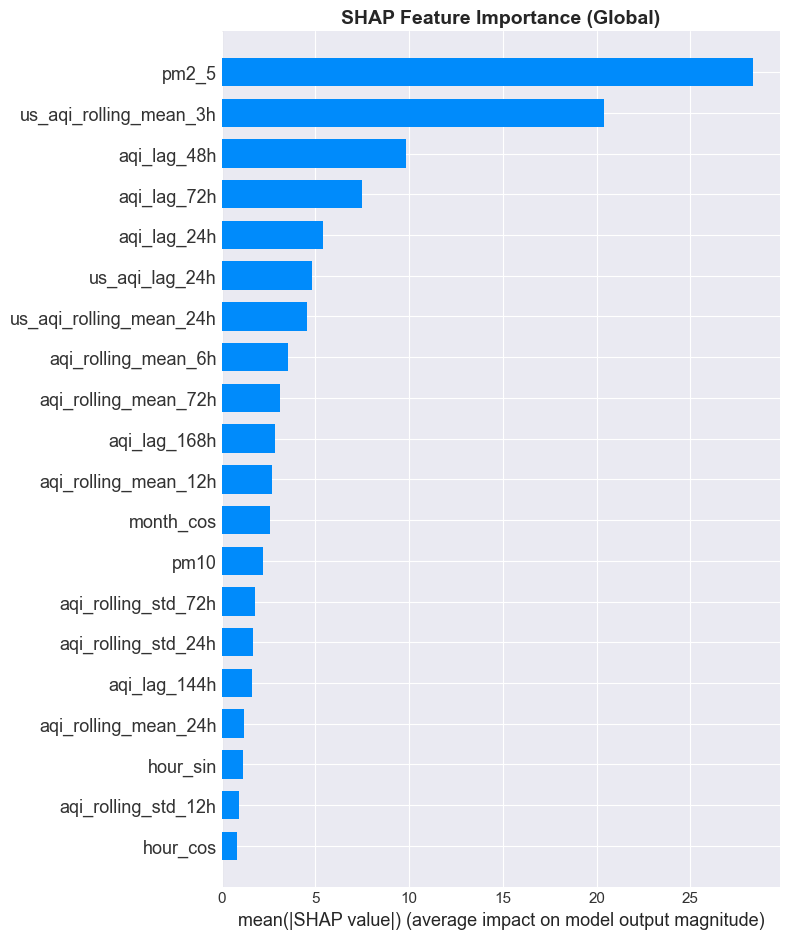

✅ Saved: shap_summary_bar.png


In [7]:
print("📊 Creating SHAP summary bar plot...\n")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_summary_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: shap_summary_bar.png")

### 6.3 Detailed Summary Plot (Beeswarm)

📊 Creating SHAP beeswarm plot...



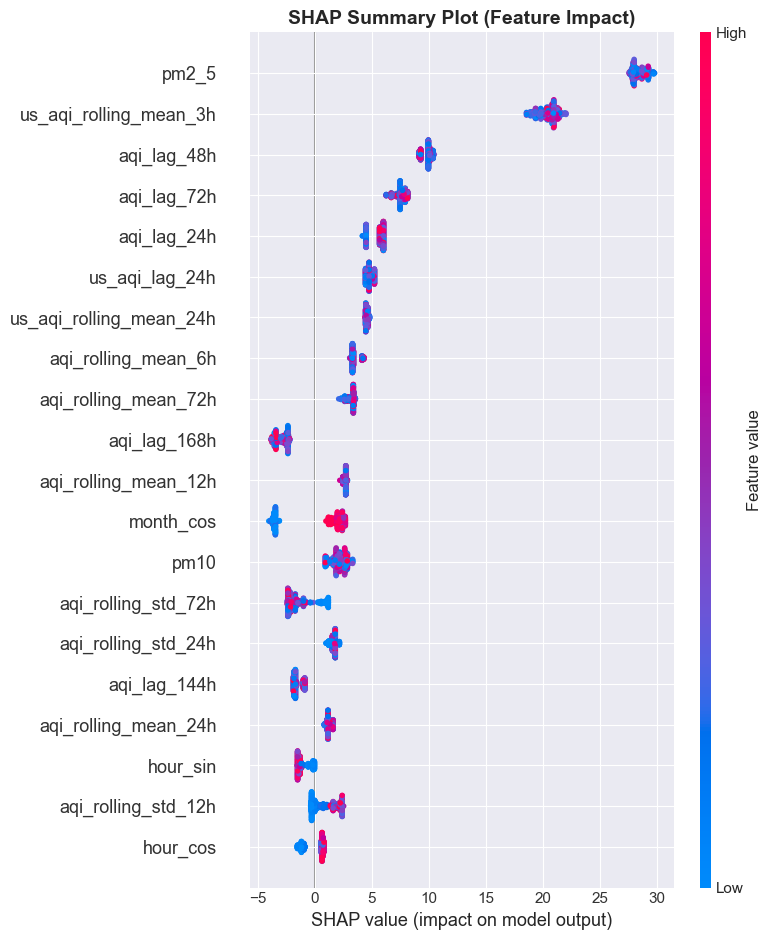

✅ Saved: shap_summary_detailed.png


In [8]:
print("📊 Creating SHAP beeswarm plot...\n")

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Summary Plot (Feature Impact)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_summary_detailed.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: shap_summary_detailed.png")

### 6.4 Dependence Plots (Top 6 Features)

📊 Creating SHAP dependence plots...



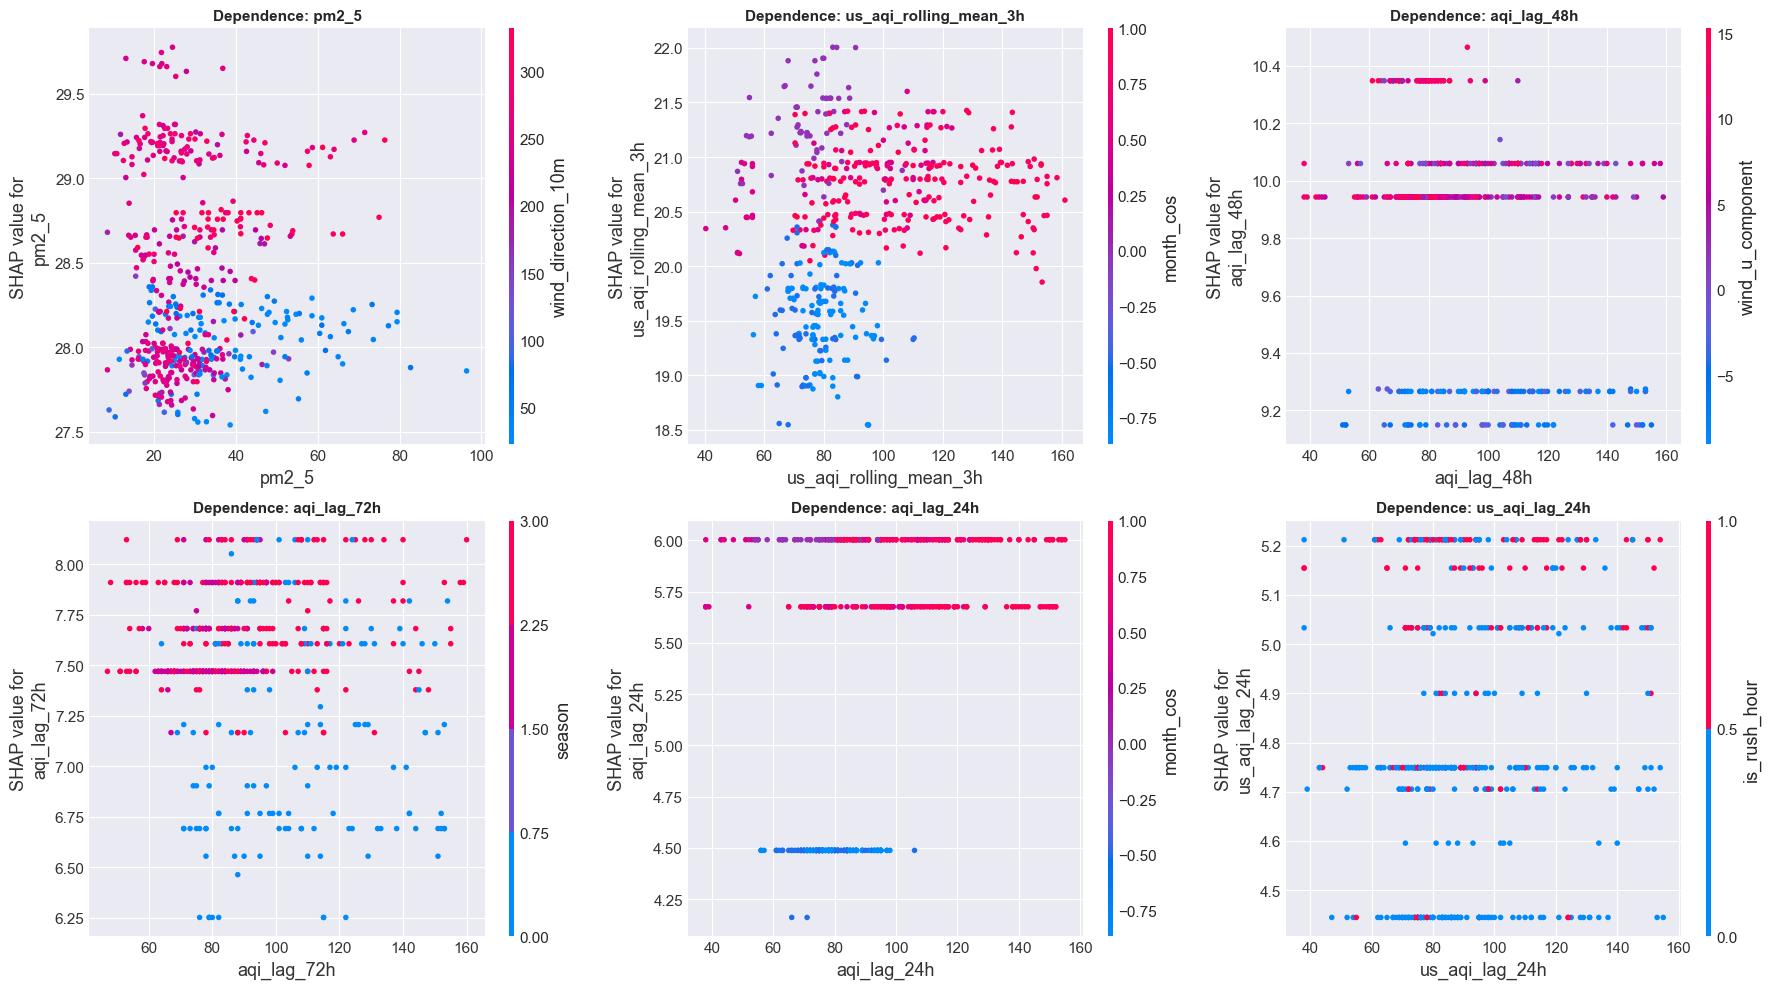

✅ Saved: shap_dependence_plots.png

Top 6 features analyzed:
   1. pm2_5
   2. us_aqi_rolling_mean_3h
   3. aqi_lag_48h
   4. aqi_lag_72h
   5. aqi_lag_24h
   6. us_aqi_lag_24h


In [9]:
print("📊 Creating SHAP dependence plots...\n")

# Get top 6 features by mean absolute SHAP value
feature_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-6:][::-1]
top_features = [feature_names[i] for i in top_features_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    shap.dependence_plot(feature, shap_values, X_test_sample, ax=axes[idx], show=False)
    axes[idx].set_title(f"Dependence: {feature}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_dependence_plots.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: shap_dependence_plots.png")
print(f"\nTop 6 features analyzed:")
for i, feat in enumerate(top_features, 1):
    print(f"   {i}. {feat}")

### 6.5 Force Plot (Individual Prediction)

📊 Creating SHAP force plot for a single prediction...



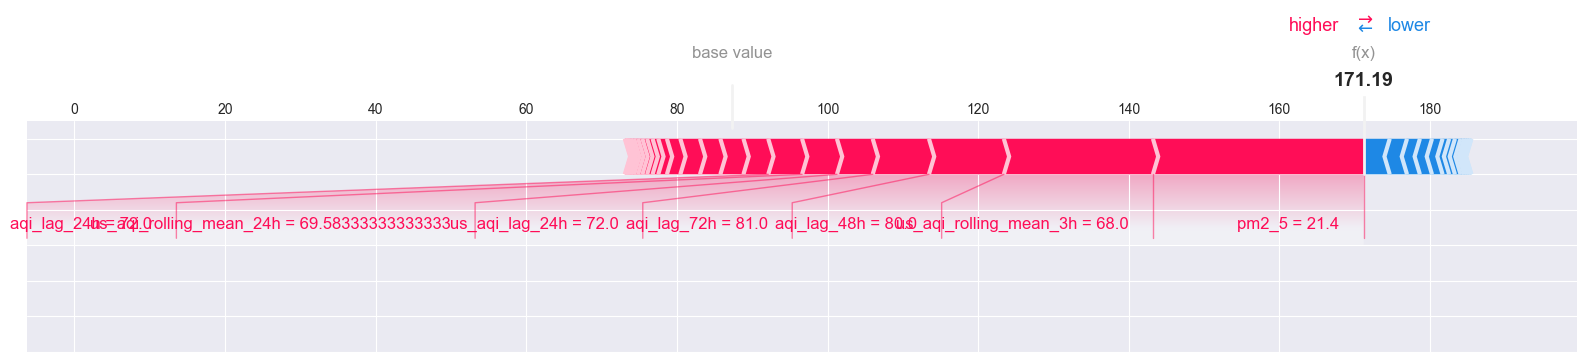

✅ Saved: shap_force_plot.png
   Sample index: 42
   Actual AQI: 73.00
   Predicted AQI: 171.19


In [10]:
print("📊 Creating SHAP force plot for a single prediction...\n")

# Select a random sample
sample_idx = 42
shap.initjs()

# Force plot
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_sample.iloc[sample_idx],
    matplotlib=True,
    show=False
)

plt.savefig(os.path.join(OUTPUT_DIR, 'shap_force_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: shap_force_plot.png")
print(f"   Sample index: {sample_idx}")
print(f"   Actual AQI: {y_test.iloc[sample_idx]:.2f}")
print(f"   Predicted AQI: {model.predict(X_test_sample.iloc[[sample_idx]])[0]:.2f}")

### 6.6 Waterfall Plot (Cumulative Feature Contributions)

📊 Creating SHAP waterfall plot...



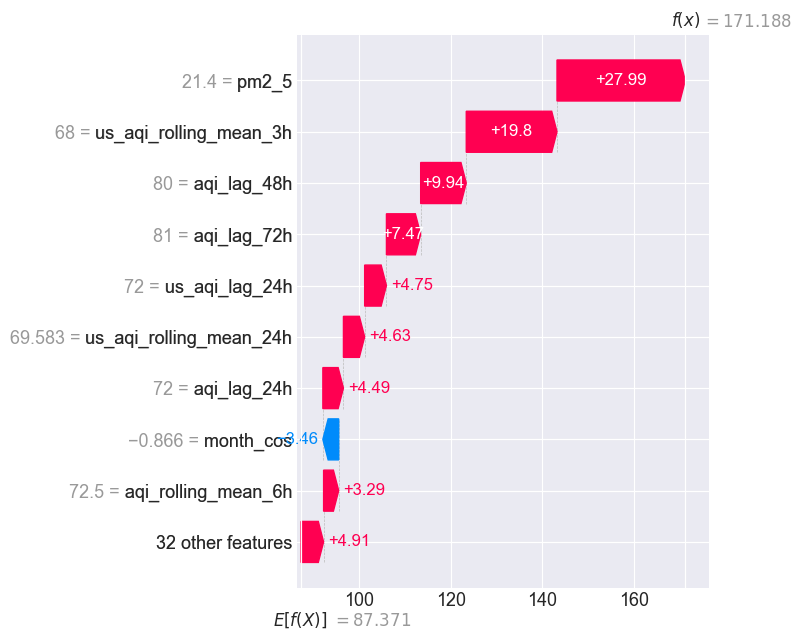

✅ Saved: shap_waterfall.png


In [11]:
print("📊 Creating SHAP waterfall plot...\n")

# Create explanation object for waterfall plot
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[sample_idx].values,
    feature_names=feature_names
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_waterfall.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: shap_waterfall.png")

## 7. LIME Analysis

### 7.1 Initialize LIME Explainer

In [12]:
print("🔍 Initializing LIME explainer...\n")

# Create LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    mode='regression',
    random_state=42
)

print("✅ LIME explainer initialized")

🔍 Initializing LIME explainer...

✅ LIME explainer initialized


### 7.2 Explain Individual Prediction

📊 Creating LIME explanation for a single prediction...



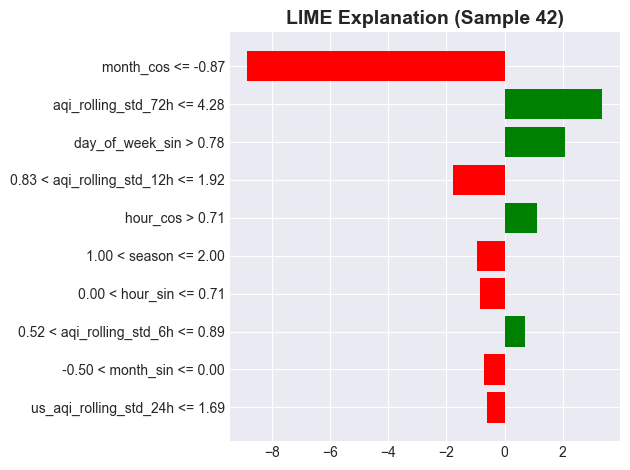

✅ Saved: lime_explanation.png

Top 10 features by LIME:
   month_cos <= -0.87: -8.8590
   aqi_rolling_std_72h <= 4.28: +3.3658
   day_of_week_sin > 0.78: +2.0879
   0.83 < aqi_rolling_std_12h <= 1.92: -1.7715
   hour_cos > 0.71: +1.1173
   1.00 < season <= 2.00: -0.9584
   0.00 < hour_sin <= 0.71: -0.8461
   0.52 < aqi_rolling_std_6h <= 0.89: +0.7060
   -0.50 < month_sin <= 0.00: -0.7016
   us_aqi_rolling_std_24h <= 1.69: -0.5946


In [13]:
print("📊 Creating LIME explanation for a single prediction...\n")

# Select the same sample as SHAP for comparison
sample_idx = 42
sample = X_test_sample.iloc[sample_idx].values

# Generate explanation
lime_exp = lime_explainer.explain_instance(
    data_row=sample,
    predict_fn=model.predict,
    num_features=10
)

# Plot explanation
fig = lime_exp.as_pyplot_figure()
plt.title(f"LIME Explanation (Sample {sample_idx})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lime_explanation.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: lime_explanation.png")
print(f"\nTop 10 features by LIME:")
for feat, weight in lime_exp.as_list():
    print(f"   {feat}: {weight:+.4f}")

### 7.3 Explain Multiple Samples

📊 Creating LIME explanations for multiple samples...



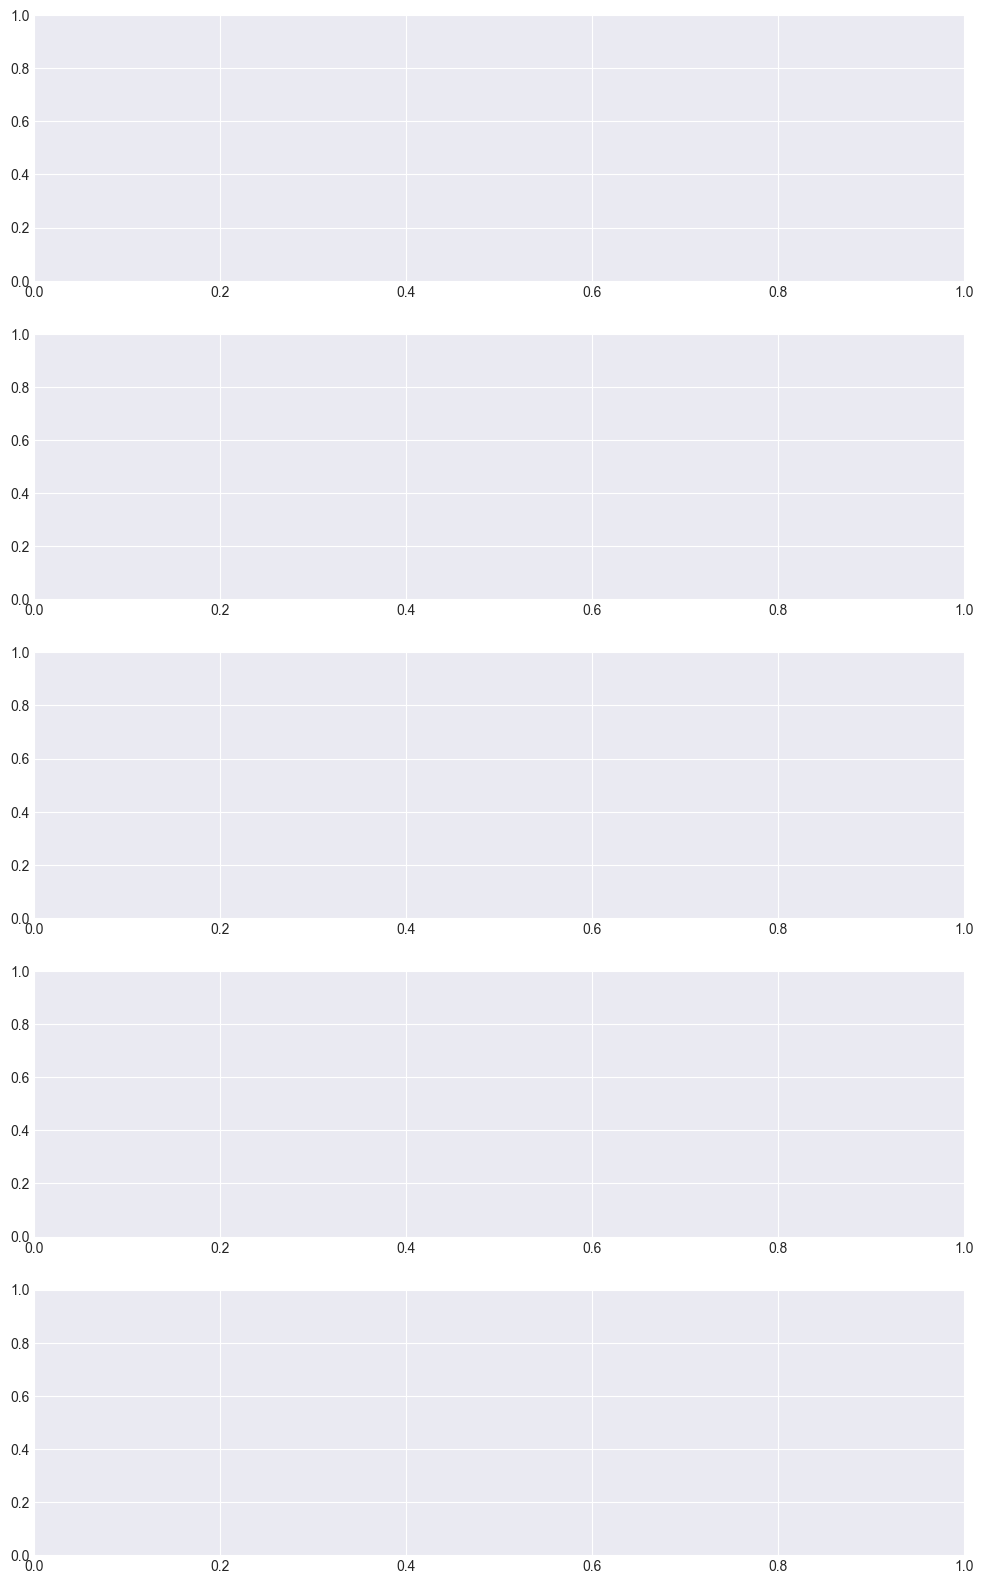

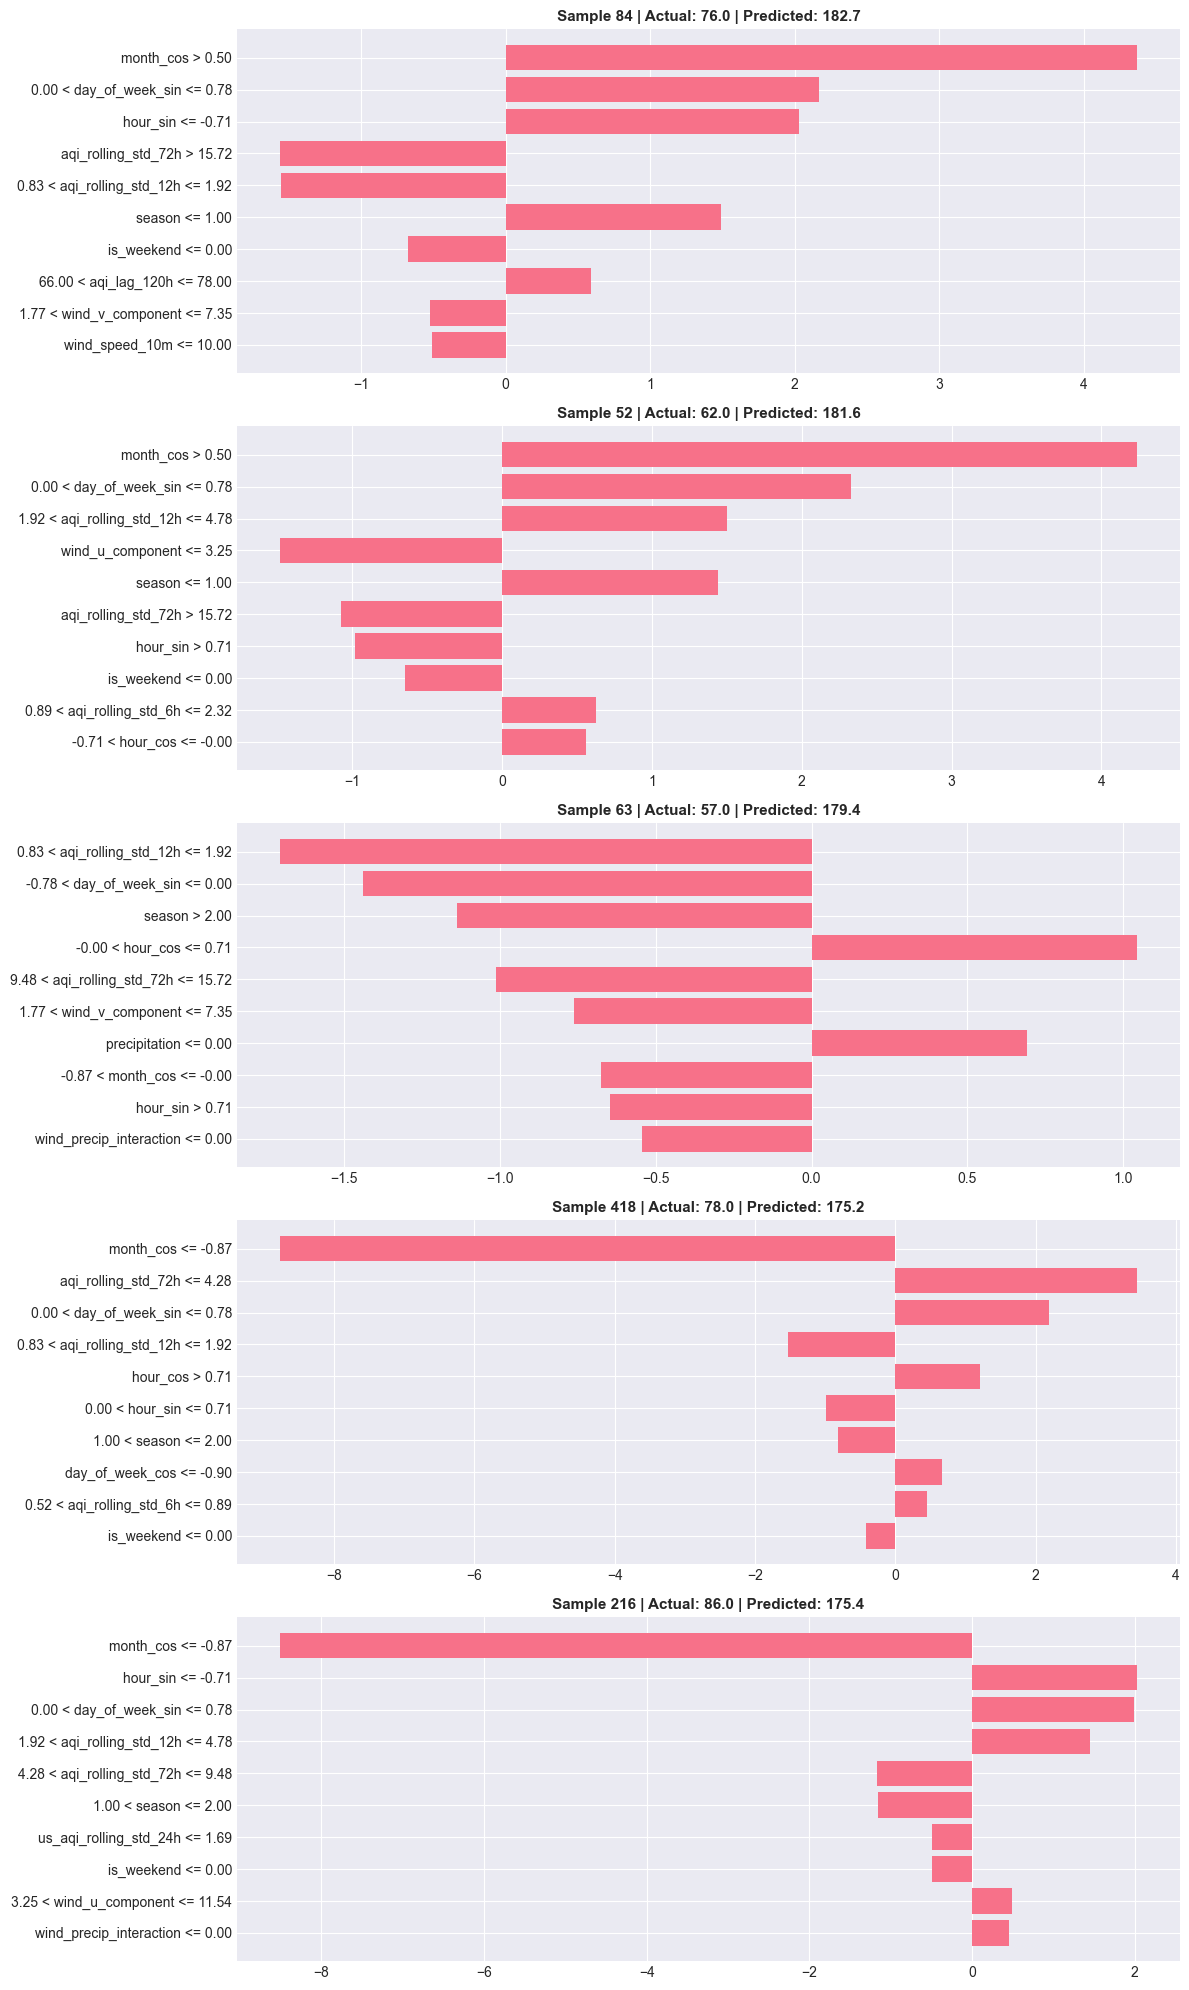

✅ Saved: lime_multiple_samples.png


In [15]:
print("📊 Creating LIME explanations for multiple samples...\n")

# Select 5 random samples
n_samples = 5
sample_indices = np.random.choice(len(X_test_sample), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 1, figsize=(12, 4*n_samples))

for idx, sample_idx in enumerate(sample_indices):
    sample = X_test_sample.iloc[sample_idx].values
    
    lime_exp = lime_explainer.explain_instance(
        data_row=sample,
        predict_fn=model.predict,
        num_features=10
    )
    
    # Get explanation as list
    exp_list = lime_exp.as_list()
    
    features = [x[0] for x in exp_list]
    weights = [x[1] for x in exp_list]
    
    axes[idx].barh(features, weights)
    axes[idx].set_title(
        f"Sample {sample_idx} | Actual: {y_test.iloc[sample_idx]:.1f} | "
        f"Predicted: {model.predict([sample])[0]:.1f}",
        fontsize=11,
        fontweight='bold'
    )
    axes[idx].invert_yaxis()


plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lime_multiple_samples.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: lime_multiple_samples.png")

## 8. Comparative Analysis: SHAP vs LIME

### 8.1 Feature Importance Comparison

In [16]:
print("📊 Comparing SHAP and LIME feature importance...\n")

# SHAP global importance
shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False)

# LIME importance (average over multiple samples)
lime_importance = {}
n_lime_samples = 100
lime_sample_indices = np.random.choice(len(X_test_sample), n_lime_samples, replace=False)

for sample_idx in lime_sample_indices:
    sample = X_test_sample.iloc[sample_idx].values
    lime_exp = lime_explainer.explain_instance(
        data_row=sample,
        predict_fn=model.predict,
        num_features=len(feature_names)
    )
    
    for feat, weight in lime_exp.as_list():
        # Extract feature name (LIME returns "feature <= value" format)
        feat_name = feat.split(' ')[0] if ' ' in feat else feat
        if feat_name not in lime_importance:
            lime_importance[feat_name] = []
        lime_importance[feat_name].append(abs(weight))

# Average LIME importance
lime_avg = {k: np.mean(v) for k, v in lime_importance.items()}
lime_df = pd.DataFrame({
    'feature': list(lime_avg.keys()),
    'lime_importance': list(lime_avg.values())
}).sort_values('lime_importance', ascending=False)

# Merge
comparison_df = shap_df.merge(lime_df, on='feature', how='outer').fillna(0)

# Normalize for comparison
comparison_df['shap_normalized'] = comparison_df['shap_importance'] / comparison_df['shap_importance'].max()
comparison_df['lime_normalized'] = comparison_df['lime_importance'] / comparison_df['lime_importance'].max()

print("✅ Feature importance calculated for both methods")
print(f"\nTop 10 features by SHAP:")
print(comparison_df.nlargest(10, 'shap_importance')[['feature', 'shap_importance']].to_string(index=False))

print(f"\nTop 10 features by LIME:")
print(comparison_df.nlargest(10, 'lime_importance')[['feature', 'lime_importance']].to_string(index=False))

📊 Comparing SHAP and LIME feature importance...

✅ Feature importance calculated for both methods

Top 10 features by SHAP:
                feature  shap_importance
                  pm2_5        28.365635
 us_aqi_rolling_mean_3h        20.414062
            aqi_lag_48h         9.831707
            aqi_lag_72h         7.509830
            aqi_lag_24h         5.415621
         us_aqi_lag_24h         4.825944
us_aqi_rolling_mean_24h         4.550641
    aqi_rolling_mean_6h         3.553931
   aqi_rolling_mean_72h         3.100718
           aqi_lag_168h         2.831744

Top 10 features by LIME:
            feature  lime_importance
          month_cos         5.883777
              -0.00         2.867285
aqi_rolling_std_72h         2.374990
    day_of_week_sin         2.030171
           hour_cos         1.987254
aqi_rolling_std_12h         1.924916
               0.83         1.588609
           hour_sin         1.580496
               1.92         1.443704
              -0.78         1

### 8.2 Side-by-Side Comparison Plot

📊 Creating SHAP vs LIME comparison plot...



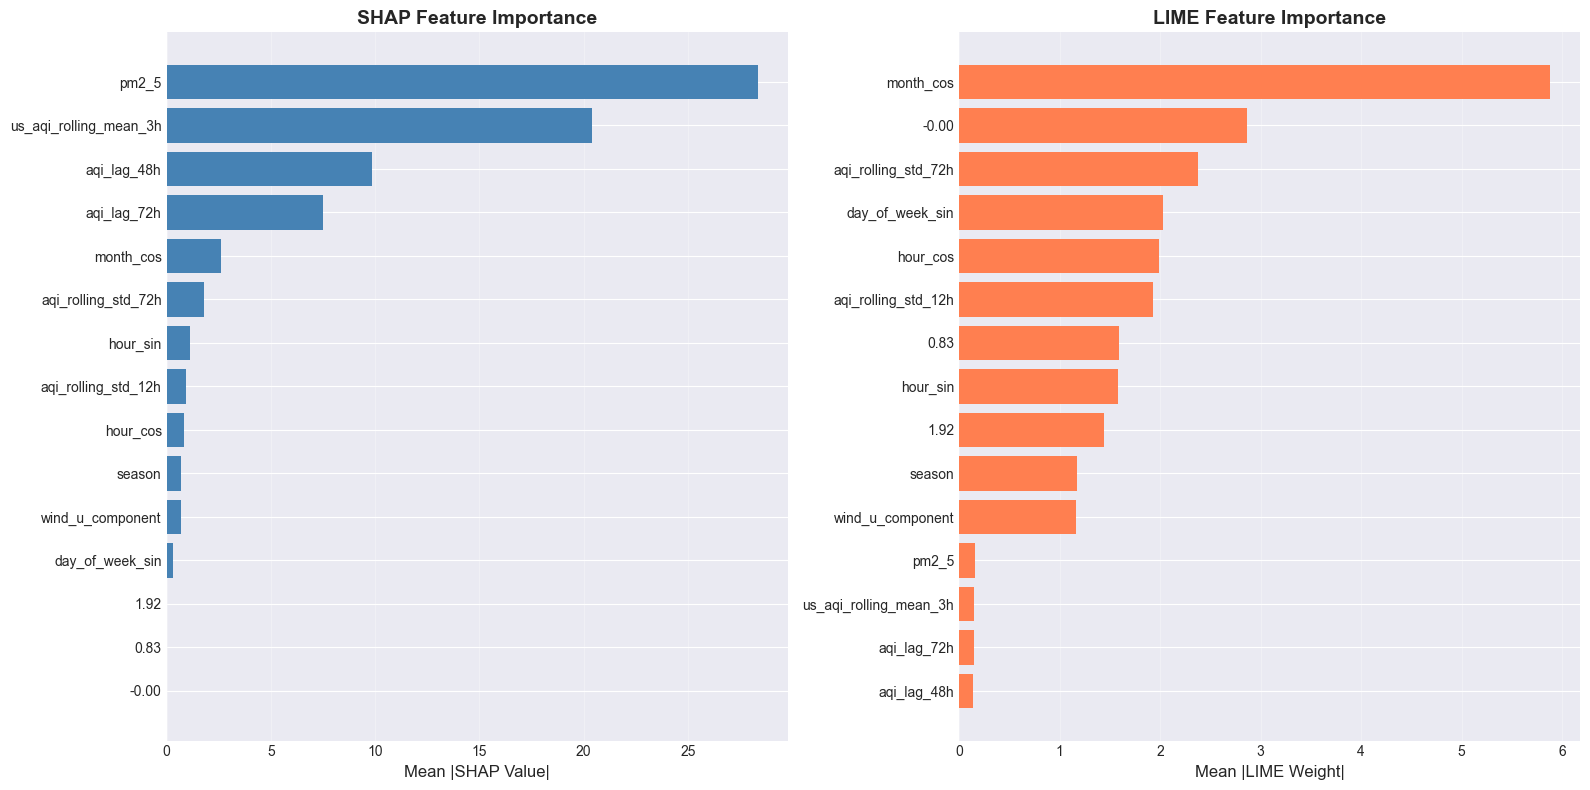

✅ Saved: shap_vs_lime_comparison.png


In [17]:
print("📊 Creating SHAP vs LIME comparison plot...\n")

# Get top 15 features by combined importance
comparison_df['combined'] = comparison_df['shap_normalized'] + comparison_df['lime_normalized']
top_15 = comparison_df.nlargest(15, 'combined')

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# SHAP
top_15_sorted = top_15.sort_values('shap_importance')
ax1.barh(top_15_sorted['feature'], top_15_sorted['shap_importance'], color='steelblue')
ax1.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax1.set_title('SHAP Feature Importance', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# LIME
top_15_sorted = top_15.sort_values('lime_importance')
ax2.barh(top_15_sorted['feature'], top_15_sorted['lime_importance'], color='coral')
ax2.set_xlabel('Mean |LIME Weight|', fontsize=12)
ax2.set_title('LIME Feature Importance', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_vs_lime_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: shap_vs_lime_comparison.png")

### 8.3 Correlation Analysis

📊 Analyzing correlation between SHAP and LIME...

Spearman correlation: 0.009
P-value: 0.9336


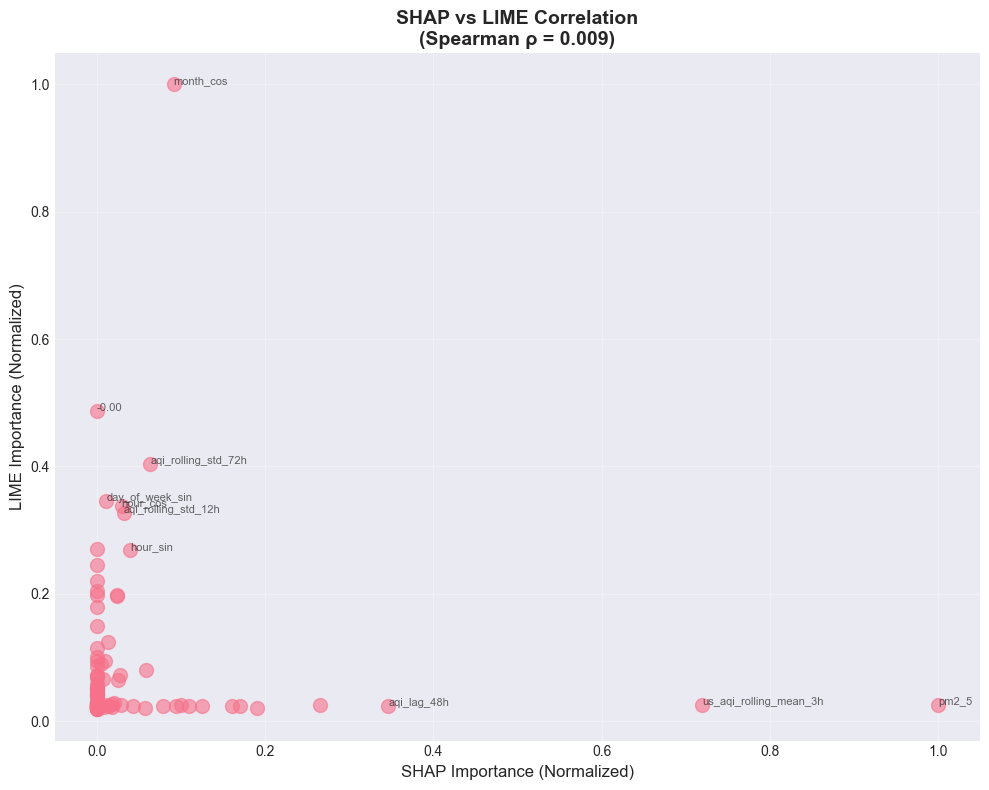


✅ Saved: shap_lime_correlation.png


In [18]:
print("📊 Analyzing correlation between SHAP and LIME...\n")

# Calculate correlation
from scipy.stats import spearmanr

# Filter to common features
common_features = comparison_df[comparison_df['lime_importance'] > 0]

correlation, p_value = spearmanr(
    common_features['shap_importance'],
    common_features['lime_importance']
)

print(f"Spearman correlation: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(common_features['shap_normalized'], 
           common_features['lime_normalized'],
           alpha=0.6, s=100)

# Add labels for top features
top_features_combined = common_features.nlargest(10, 'combined')
for _, row in top_features_combined.iterrows():
    plt.annotate(row['feature'], 
                (row['shap_normalized'], row['lime_normalized']),
                fontsize=8, alpha=0.7)

plt.xlabel('SHAP Importance (Normalized)', fontsize=12)
plt.ylabel('LIME Importance (Normalized)', fontsize=12)
plt.title(f'SHAP vs LIME Correlation\n(Spearman ρ = {correlation:.3f})', 
         fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_lime_correlation.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved: shap_lime_correlation.png")

## 9. Key Insights and Summary

In [19]:
print("="*70)
print("📋 KEY INSIGHTS")
print("="*70)

# Top features by both methods
shap_top_10 = set(comparison_df.nlargest(10, 'shap_importance')['feature'])
lime_top_10 = set(comparison_df.nlargest(10, 'lime_importance')['feature'])
common_top = shap_top_10.intersection(lime_top_10)

print(f"\n1️⃣ Top 10 Features Agreement:")
print(f"   Common features in both top 10: {len(common_top)}/10")
print(f"   Agreement rate: {len(common_top)/10*100:.1f}%")

print(f"\n2️⃣ Common Top Features:")
for i, feat in enumerate(sorted(common_top), 1):
    print(f"   {i}. {feat}")

print(f"\n3️⃣ Method Correlation:")
print(f"   Spearman correlation: {correlation:.3f}")
if correlation > 0.7:
    print(f"   Interpretation: Strong agreement between methods")
elif correlation > 0.4:
    print(f"   Interpretation: Moderate agreement between methods")
else:
    print(f"   Interpretation: Weak agreement between methods")

print(f"\n4️⃣ Model Performance:")
print(f"   Test R²: {metrics['test_r2']:.3f}")
print(f"   Test MAE: {metrics['test_mae']:.2f}")
print(f"   CV R²: {metrics['cv_mean_test_r2']:.3f} ± {metrics['cv_std_test_r2']:.3f}")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)
print(f"\nAll visualizations saved to: {OUTPUT_DIR}")

📋 KEY INSIGHTS

1️⃣ Top 10 Features Agreement:
   Common features in both top 10: 0/10
   Agreement rate: 0.0%

2️⃣ Common Top Features:

3️⃣ Method Correlation:
   Spearman correlation: 0.009
   Interpretation: Weak agreement between methods

4️⃣ Model Performance:
   Test R²: 0.632
   Test MAE: 10.23
   CV R²: 0.526 ± 0.135

✅ ANALYSIS COMPLETE

All visualizations saved to: C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\notebooks\interpretability_outputs


## 10. Export Results

In [20]:
print("💾 Exporting results...\n")

# Export feature importance comparison
comparison_df.to_csv(
    os.path.join(OUTPUT_DIR, 'feature_importance_comparison.csv'),
    index=False
)
print("✅ Saved: feature_importance_comparison.csv")

# Export summary statistics
summary = {
    'model': selected_model_name,
    'test_r2': metrics['test_r2'],
    'test_mae': metrics['test_mae'],
    'cv_r2_mean': metrics['cv_mean_test_r2'],
    'cv_r2_std': metrics['cv_std_test_r2'],
    'n_features': len(feature_names),
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test),
    'shap_lime_correlation': correlation,
    'top_10_agreement': len(common_top)/10
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(
    os.path.join(OUTPUT_DIR, 'analysis_summary.csv'),
    index=False
)
print("✅ Saved: analysis_summary.csv")

print(f"\n📁 All results exported to: {OUTPUT_DIR}")
print("\n🎉 Model interpretability analysis complete!")

💾 Exporting results...

✅ Saved: feature_importance_comparison.csv
✅ Saved: analysis_summary.csv

📁 All results exported to: C:\Users\Administrator\OneDrive\Desktop\Pearls_AQI\notebooks\interpretability_outputs

🎉 Model interpretability analysis complete!
